In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
networks = pd.read_csv("networkanomalydataset.csv")

# Brief Display of Dataset
networks.head()
networks.info()
networks.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1654 entries, 0 to 1653
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Inbound Rate(bit/s)                1654 non-null   float64
 1   Outbound Rate(bit/s)               1654 non-null   float64
 2   Inbound Bandwidth Utilization(%)   1654 non-null   float64
 3   Outbound Bandwidth Utilization(%)  1654 non-null   float64
 4   Label                              1654 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 64.7 KB


,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Label
count,1.654000e+03,1.654000e+03,1.654000e+03,1.654000e+03,1654.000000
mean,2.062035e-16,-1.374690e-16,-6.873448e-17,2.062035e-16,0.500000
std,1.000302e+00,1.000302e+00,1.000302e+00,1.000302e+00,0.500151
min,-8.587873e-01,-8.451589e-01,-8.587677e-01,-8.450422e-01,0.000000
25%,-8.071507e-01,-8.063695e-01,-8.072172e-01,-8.064441e-01,0.000000
50%,-7.555341e-01,-7.747574e-01,-7.554490e-01,-7.751713e-01,0.500000
75%,9.628647e-01,1.112895e+00,9.627478e-01,1.112738e+00,1.000000
max,2.122913e+00,1.997753e+00,2.122901e+00,1.998350e+00,1.000000


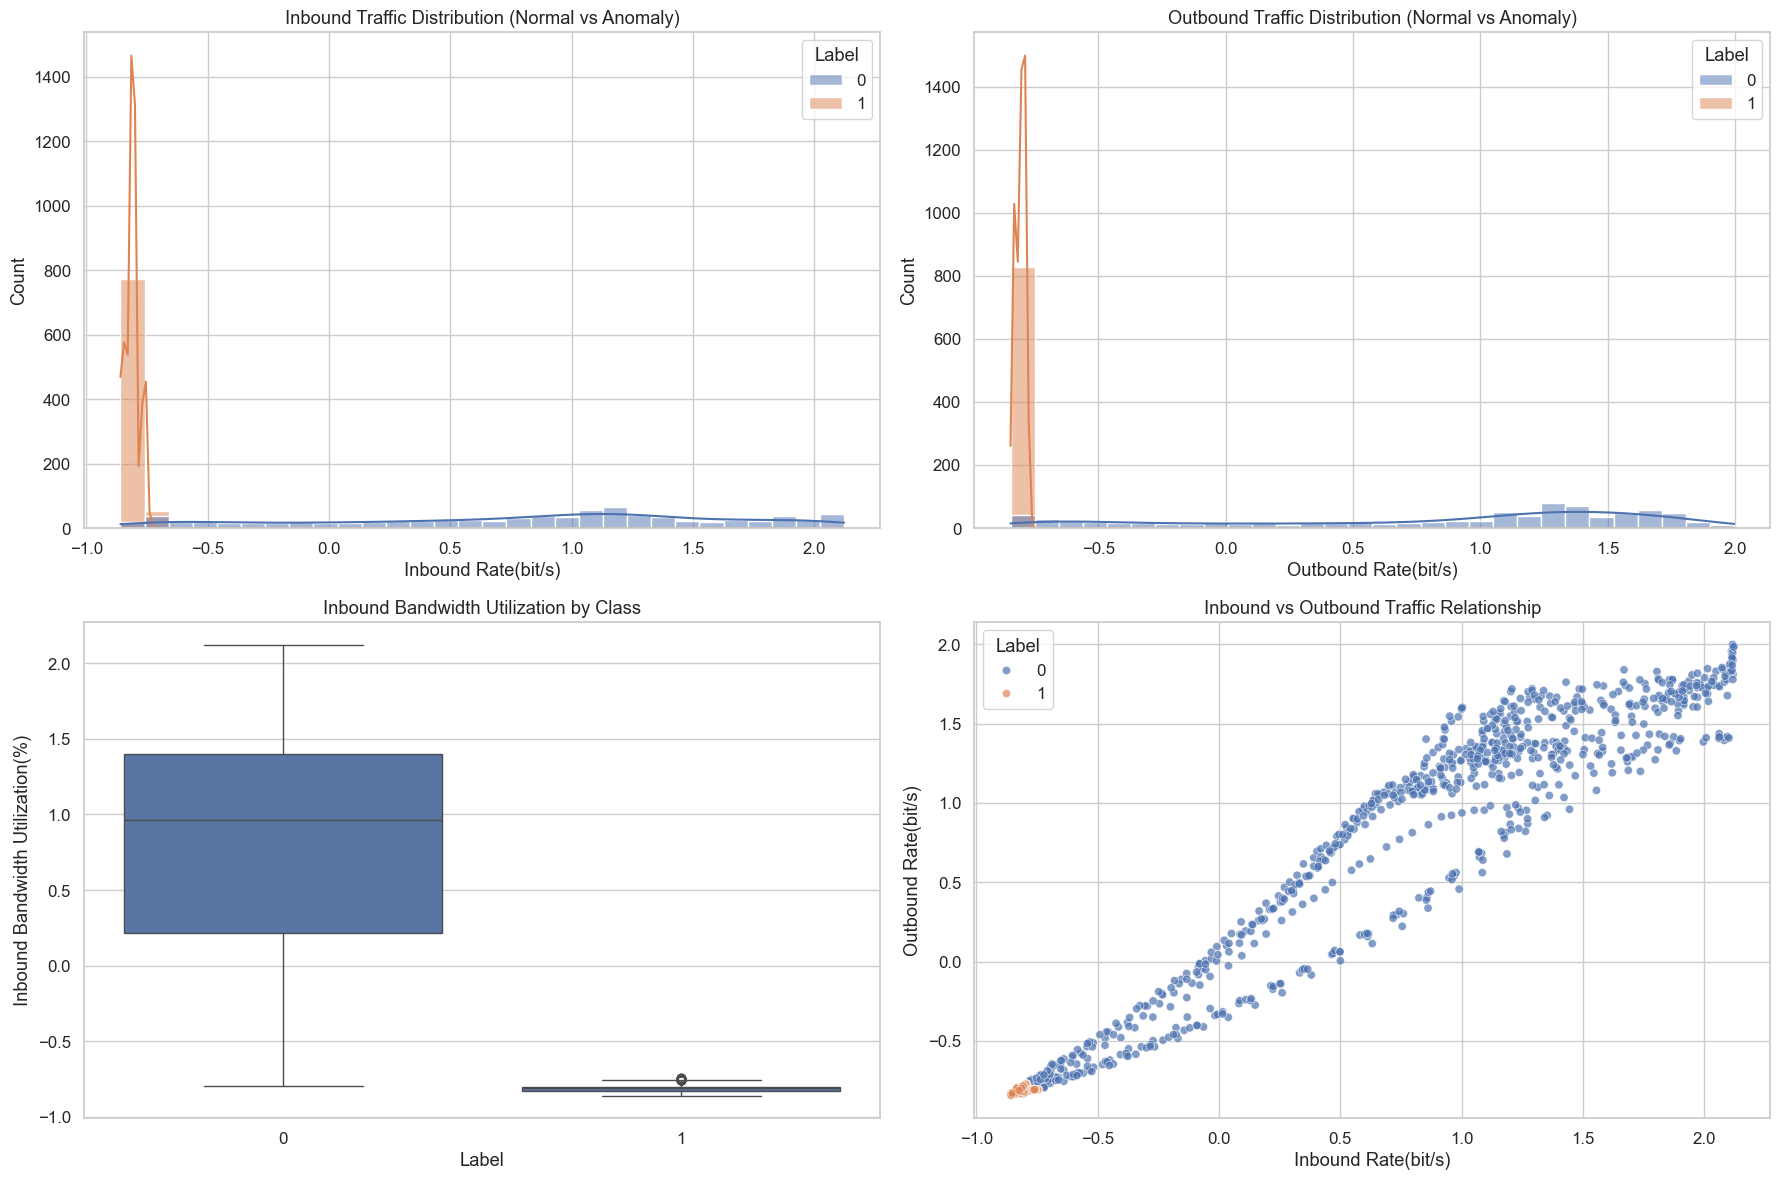

In [3]:
# ==============================
# Exploratory Data Analysis - Network Anomaly
# ==============================
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(18, 12))

# ------------------------------
# 1. Inbound Rate Distribution
# ------------------------------
plt.subplot(2, 2, 1)
sns.histplot(
    data=networks,
    x="Inbound Rate(bit/s)",
    hue="Label",
    bins=30,
    kde=True
)
plt.title("Inbound Traffic Distribution (Normal vs Anomaly)")

# ------------------------------
# 2. Outbound Rate Distribution
# ------------------------------
plt.subplot(2, 2, 2)
sns.histplot(
    data=networks,
    x="Outbound Rate(bit/s)",
    hue="Label",
    bins=30,
    kde=True
)
plt.title("Outbound Traffic Distribution (Normal vs Anomaly)")

# ------------------------------
# 3. Bandwidth Utilization
# ------------------------------
plt.subplot(2, 2, 3)
sns.boxplot(
    data=networks,
    x="Label",
    y="Inbound Bandwidth Utilization(%)"
)
plt.title("Inbound Bandwidth Utilization by Class")

# ------------------------------
# 4. Feature Relationship
# ------------------------------
plt.subplot(2, 2, 4)
sns.scatterplot(
    data=networks,
    x="Inbound Rate(bit/s)",
    y="Outbound Rate(bit/s)",
    hue="Label",
    alpha=0.7
)
plt.title("Inbound vs Outbound Traffic Relationship")

plt.tight_layout()
plt.show()

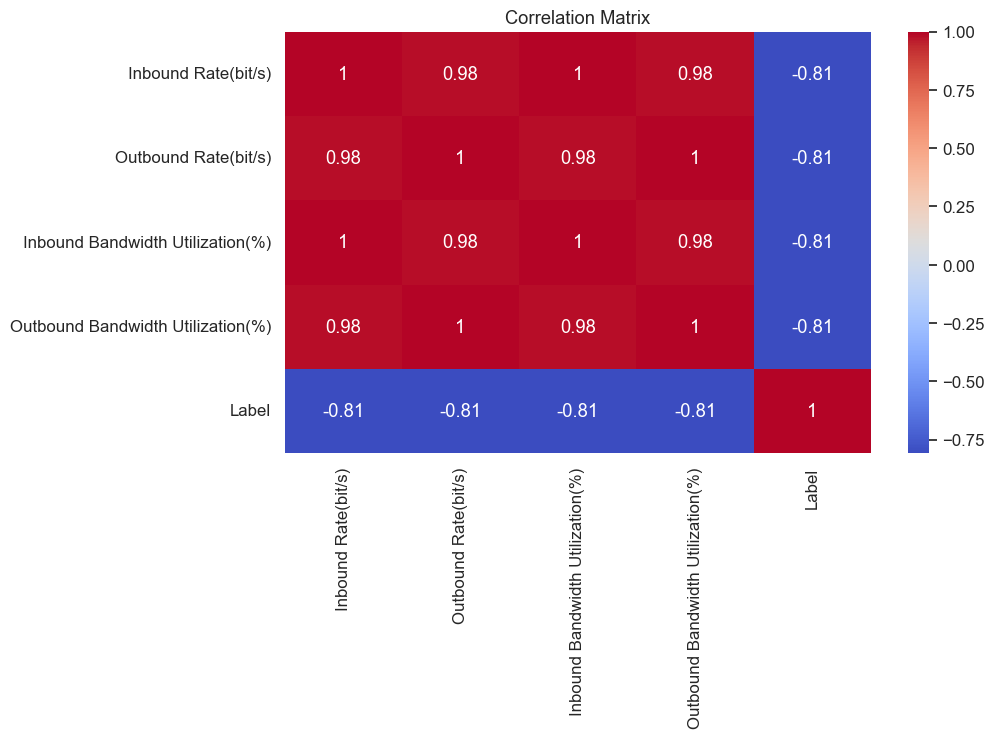

In [5]:
plt.figure(figsize=(18, 12))

# Correlation Heatmap
plt.subplot(2, 2, 1)
sns.heatmap(networks.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

# Print
plt.tight_layout()
plt.show()

# Feature Engineering: Time-Aware Approximation Without Explicit Timestamps

This dataset does not include explicit timestamps, making formal time-series forecasting methods methodologically inappropriate. To address this limitation, a preliminary analysis was conducted to evaluate whether the dataset exhibits sequential behavior. A row-to-row difference analysis showed that adjacent observations change gradually and consistently, supporting the assumption that the data is ordered sequentially.

Based on this validation, the row index is treated as a proxy for temporal progression, enabling the introduction of time-aware feature engineering. This approach incorporates lagged variables and rolling statistical measures to approximate short-term temporal dependencies within the data.

Lag features capture prior network states, while rolling statistics model recent baseline behavior and variability. Together, these features allow the model to assess whether current observations deviate from recent patterns—an essential characteristic of anomaly detection in networked systems.

To ensure methodological rigor, rolling features are computed using shifted values only, preventing data leakage by excluding the current observation from its own historical summary.

This approach provides a defensible and practical method for approximating temporal dynamics in a static dataset, enabling the detection of fluctuations, instability, and deviations that are critical in mission-critical cybersecurity and aerospace environments.

In [6]:
# ============================================================
# Verifying Assumption: Rows are in Chronological Order
# ============================================================

# 1. Load a clean copy of the dataset
networks_fe = networks.copy().reset_index(drop=True)

# 2. Inspect row-to-row differences
row_diff_summary = networks_fe[features].diff().describe().T
print("Row-to-row difference summary:")
print(row_diff_summary)

Row-to-row difference summary:
                                    count      mean       std       min  \
Inbound Rate(bit/s)                1653.0 -0.001062  0.076556 -1.902645   
Outbound Rate(bit/s)               1653.0 -0.001232  0.071153 -2.111724   
Inbound Bandwidth Utilization(%)   1653.0 -0.001062  0.076564 -1.902742   
Outbound Bandwidth Utilization(%)  1653.0 -0.001233  0.071187 -2.112204   

                                        25%       50%       75%       max  
Inbound Rate(bit/s)               -0.034030  0.004125  0.038831  0.247587  
Outbound Rate(bit/s)              -0.022836  0.005409  0.031644  0.132957  
Inbound Bandwidth Utilization(%)  -0.034135  0.004260  0.038778  0.247585  
Outbound Bandwidth Utilization(%) -0.023001  0.005494  0.032165  0.132949  


# Validation of Sequential Assumption

Before introducing time-aware features, a row-to-row difference analysis was conducted to assess whether adjacent observations exhibit sequential behavior.

The analysis shows that consecutive differences have a mean near zero, low variability (≈ 0.07), and a narrow interquartile range (±0.03), indicating that changes between observations are generally small and stable. While occasional larger deviations are present, these likely reflect anomalous events or transient system fluctuations rather than random noise.

These findings suggest that adjacent rows exhibit continuity and are not independent, supporting the assumption that the dataset is ordered sequentially. Based on this evidence, the row index is treated as a proxy for temporal progression, enabling the use of lagged and rolling features to approximate short-term temporal dependencies.

Although this does not constitute true time-series modeling, it provides a defensible and practical approach for capturing sequential behavior in the absence of explicit timestamps. In operational network environments, such smooth transitions are expected, as traffic patterns typically evolve gradually rather than randomly between observations. Sudden large deviations may therefore represent abnormal system behavior, reinforcing the relevance of temporal feature engineering for anomaly detection.

In [10]:
# ============================================================
# FEATURE ENGINEERING: Lag + Rolling Features
# ============================================================

networks_fe = networks.copy().reset_index(drop=True)

# 2. Define feature 
features = [
    "Inbound Rate(bit/s)",
    "Outbound Rate(bit/s)",
    "Inbound Bandwidth Utilization(%)",
    "Outbound Bandwidth Utilization(%)"
]

target = "Label"

# 3. Lag Features
lag_steps = [1, 2]

for col in features:
    for lag in lag_steps:
        networks_fe[f"{col}_lag{lag}"] = networks_fe[col].shift(lag)

# 4. Rolling Features 
window = 5

for col in features:
    shifted = networks_fe[col].shift(1)
    
    networks_fe[f"{col}_roll_mean_{window}"] = shifted.rolling(window).mean()
    networks_fe[f"{col}_roll_std_{window}"] = shifted.rolling(window).std()

# 5. Deviation Features (KEY FOR ANOMALY DETECTION)
for col in features:
    roll_mean = f"{col}_roll_mean_{window}"
    roll_std = f"{col}_roll_std_{window}"
    
    # Difference from local baseline
    networks_fe[f"{col}_delta"] = networks_fe[col] - networks_fe[roll_mean]
    
    # Z-score (normalized deviation)
    networks_fe[f"{col}_zscore"] = (
        (networks_fe[col] - networks_fe[roll_mean]) /
        networks_fe[roll_std].replace(0, np.nan)
    )

# 6. Drop NaNs
networks_fe = networks_fe.dropna().reset_index(drop=True)

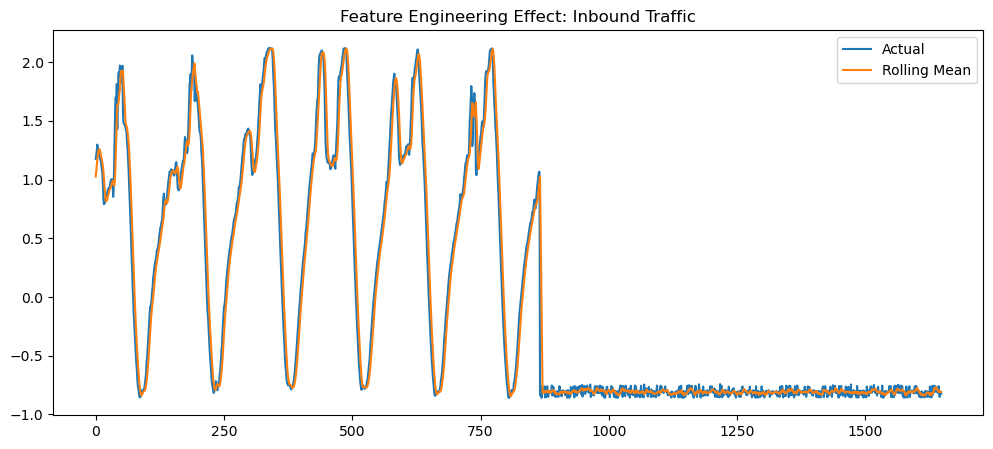

In [11]:
plt.figure(figsize=(12,5))

plt.plot(networks_fe["Inbound Rate(bit/s)"], label="Actual")
plt.plot(networks_fe[f"Inbound Rate(bit/s)_roll_mean_{window}"], label="Rolling Mean")

plt.title("Feature Engineering Effect: Inbound Traffic")
plt.legend()
plt.show()

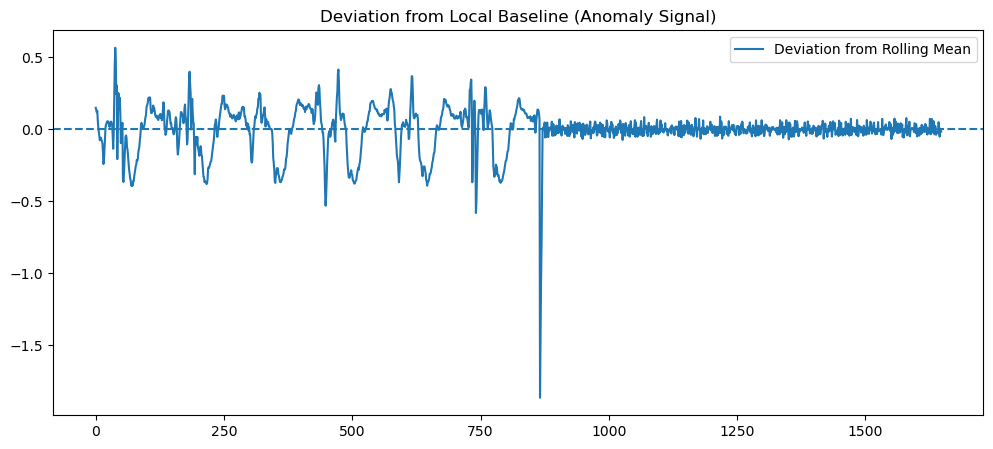

In [12]:
plt.figure(figsize=(12,5))

delta = networks_fe["Inbound Rate(bit/s)"] - networks_fe[f"Inbound Rate(bit/s)_roll_mean_{window}"]

plt.plot(delta, label="Deviation from Rolling Mean")
plt.axhline(0, linestyle="--")

plt.title("Deviation from Local Baseline (Anomaly Signal)")
plt.legend()
plt.show()

The deviation from the rolling mean highlights how far each observation departs from its recent baseline. Larger deviations may correspond to anomalous behavior, reinforcing the importance of deviation-based features in the modeling stage.